<a href="https://colab.research.google.com/github/ALAIKBITTUQOH/Erosi-dan-Dilasi_pada_Morfologi_Citra/blob/main/Dilasai%2C_Erosi_pada_Morfologi_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

pip install opencv-python matplotlib

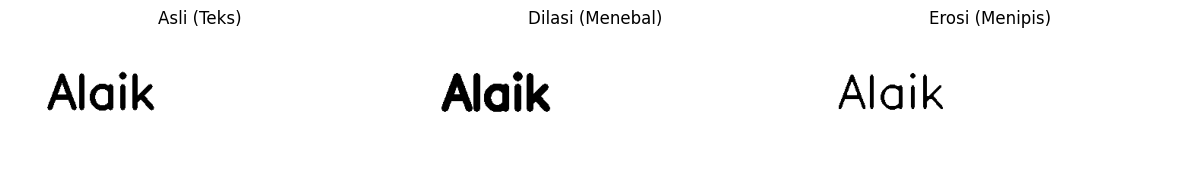

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membuat gambar kosong (hitam)
canvas = np.zeros((200, 500), dtype=np.uint8)

# 2. Menuliskan teks ke gambar
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(canvas, 'Alaik', (50, 100), font, 2, (255), thickness=5)

# 3. Binarisasi citra (background hitam, teks putih → ubah jadi teks putih di background hitam)
binary = cv2.threshold(canvas, 127, 255, cv2.THRESH_BINARY_INV)[1]

# 4. Structuring element (kernel)
kernel = np.ones((3, 3), np.uint8)

# 5. Operasi morfologi
eroded = cv2.erode(binary, kernel, iterations=1)
dilated = cv2.dilate(binary, kernel, iterations=1)

# 6. Tampilkan semua hasil
titles = ['Asli (Teks)', 'Dilasi (Menebal)', 'Erosi (Menipis)']
images = [binary, eroded, dilated]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving s_Prasasti.jpg to s_Prasasti (18).jpg


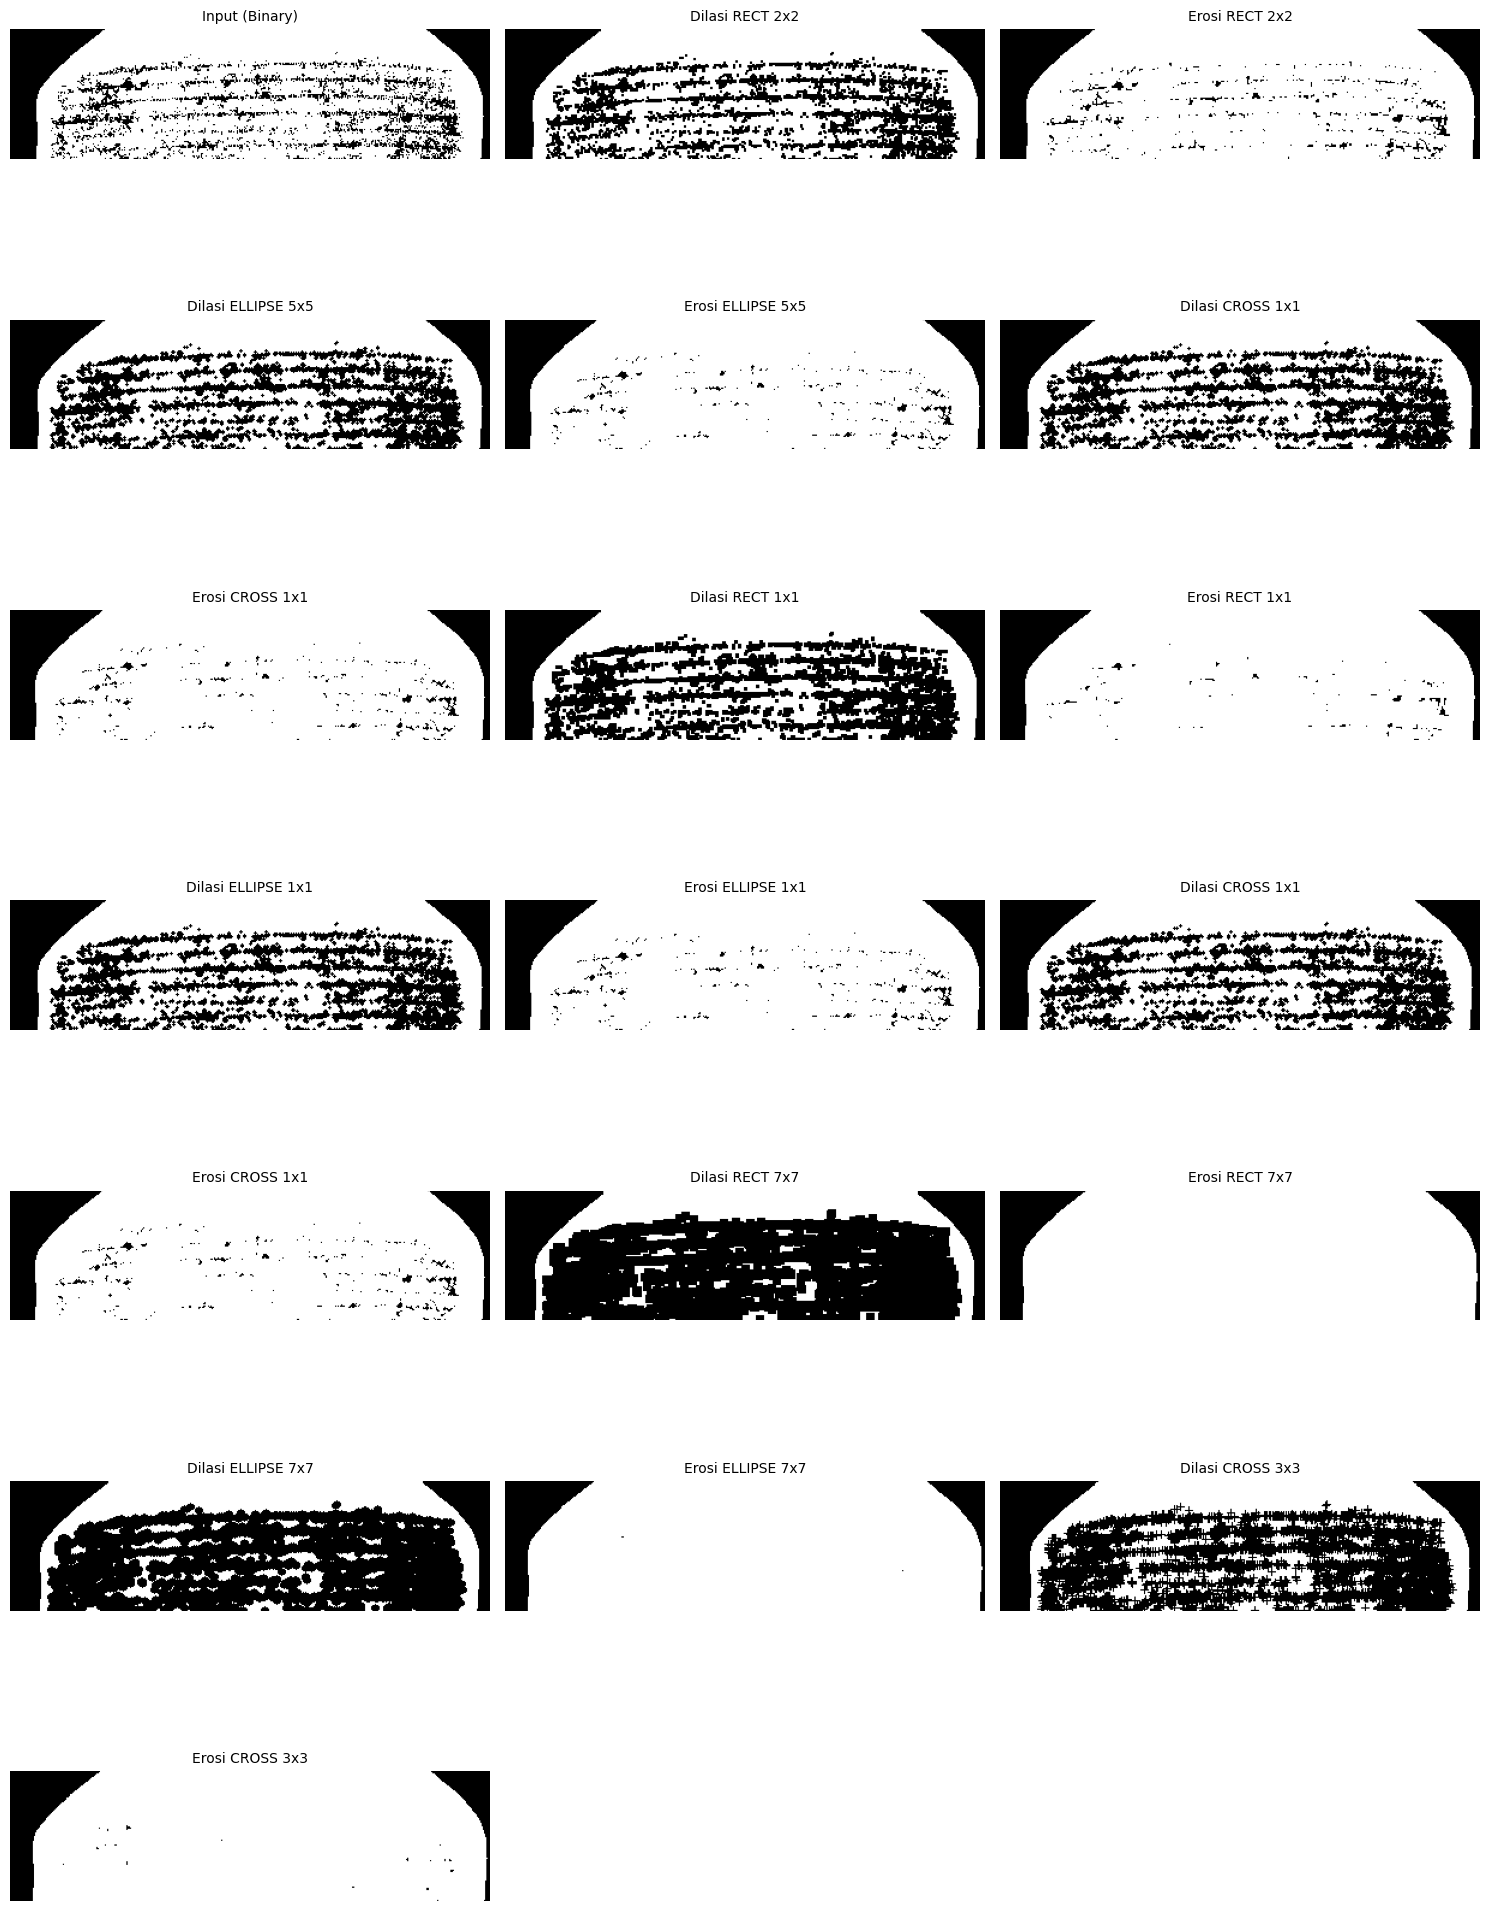

In [34]:
# --- STEP 1: Import Library ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

# --- STEP 2: Upload Gambar ---
uploaded = files.upload()

# Ambil nama file yang di-upload
filename = next(iter(uploaded))

# Baca gambar dalam mode grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# --- STEP 3: Binarisasi Gambar (pastikan teks jadi putih, background hitam) ---
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# --- STEP 4: Definisikan 9 Structuring Elements ---
strels = [
    ("RECT 2x2", cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))),  # Erosi lebih tipis
    ("ELLIPSE 5x5", cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))),
    ("CROSS 1x1", cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))),
    ("RECT 1x1", cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))),
    ("ELLIPSE 1x1", cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))),
    ("CROSS 1x1", cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))),
    ("RECT 7x7", cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))),  # Dilasi lebih tebal
    ("ELLIPSE 7x7", cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))),
    ("CROSS 3x3", cv2.getStructuringElement(cv2.MORPH_CROSS, (7, 7))),
]

# --- STEP 5: Lakukan Erosi & Dilasi dan Simpan Hasil ---
titles = ["Input (Binary)"]
images = [binary]

for name, strel in strels:
    eroded = cv2.erode(binary, strel)
    dilated = cv2.dilate(binary, strel)

    titles.append(f"Dilasi {name}")
    images.append(eroded)
    titles.append(f"Erosi {name}")
    images.append(dilated)

# --- STEP 6: Tampilkan Semua Gambar ---
n = len(images)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(15, rows * 3))

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()